In [44]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

df = pd.read_csv('../../Our Datasets/features_sample_match_new.csv')

start_types_wants = ['pass_interception', 'recovery']

df = df[df['start_type'].isin(start_types_wants)]

df['is_drawing'] = np.where(df['game_state'] == 'drawing', 1, 0)

df['is_middle_third'] = np.where(df['third_start'] == 'middle', 1, 0)

df = df.loc[df['team_out_of_possession_phase_type'] != 'defending_direct']

df['team_out_of_possession_phase_type'] = (
    df['team_out_of_possession_phase_type']
        .replace({
            'defending_set_play': 'set_play',
            'defending_quick_break': 'transition/quick_break',
            'defending_transition': 'transition/quick_break',
            'chaotic': 'chaotic/disruption',
            'disruption': 'chaotic/disruption'
        })
)


# dropping irrelevant columns
cols_to_drop = ['start_type', 'end_type', 'error', 
                'dist_to_near_goal', 'dist_to_far_goal', 'third_end', 'game_state', 'n_passing_options_dangerous_not_difficult', 'third_start',
                'n_forward_options', 'd_nearest_opp', 'd_nearest_team', 'mean_team_dist', 'n_opp_within5', 'max_player_targeted_xthreat']

df = df.drop(columns=cols_to_drop)

target_col = "player_targeted_dangerous"
df = df[df[target_col].notna()]

og_df = df.copy()

og_df["row_index"] = og_df.index

classifiers_cols_to_drop = ['Unique ID', 'match_id', 'event_index', 'frame_anchor', 'event_row_index', 'source_file', 'rec_player_id', 'rec_team_short']

df = df.drop(columns=classifiers_cols_to_drop)


In [45]:
df = pd.get_dummies(df, columns=["team_out_of_possession_phase_type"], prefix="oop_phase")

In [46]:
df

,dist_to_attacking_goal,player_targeted_dangerous,is_drawing,is_middle_third,oop_phase_chaotic/disruption,oop_phase_high_block,oop_phase_low_block,oop_phase_medium_block,oop_phase_set_play,oop_phase_transition/quick_break
0,99.575170,0.0,1,0,False,True,False,False,False,False
3,34.427403,0.0,1,0,True,False,False,False,False,False
14,51.188596,1.0,1,1,True,False,False,False,False,False
19,47.054798,1.0,1,1,True,False,False,False,False,False
20,72.213891,1.0,1,1,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
5842,46.590627,0.0,0,1,True,False,False,False,False,False
5845,71.880025,0.0,0,0,True,False,False,False,False,False
5847,60.018211,0.0,0,1,True,False,False,False,False,False
5848,78.036013,0.0,0,0,True,False,False,False,False,False


### Dangerous means if the probability of a goal being scored in the next 10 seconds (xthreat) is greater than 0.02

In [47]:
df_model = df.copy()

X = df_model.drop(columns=["player_targeted_dangerous"])
y = df_model["player_targeted_dangerous"].astype(int)

df_model["row_index"] = df_model.index
row_ids = df_model["row_index"]

X_train, X_test, y_train, y_test, row_train, row_test = train_test_split(
    X, y, row_ids, test_size=0.15, random_state=42
)

In [48]:
rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [5, 10, None],
    "min_samples_leaf": [2, 5, 10],
    "max_features": [0.3, 0.5, 1]
}

rf_grid = GridSearchCV(
    rf_base,
    rf_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train, y_train)

print("✅ Best RF Params:", rf_grid.best_params_)
print("✅ Best RF CV AUC:", rf_grid.best_score_)

best_rf = rf_grid.best_estimator_


Fitting 5 folds for each of 81 candidates, totalling 405 fits
✅ Best RF Params: {'max_depth': 5, 'max_features': 0.3, 'min_samples_leaf': 10, 'n_estimators': 300}
✅ Best RF CV AUC: 0.7417607443265537


In [49]:
pos = y_train.sum()
neg = (y_train == 0).sum()
scale = neg / pos

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale,
    subsample=0.8
)

xgb_param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [2, 3, 4, None],
    "learning_rate": [0.01, 0.05, .1],
    "min_child_weight": [5, 10, 20]
}

xgb_grid = GridSearchCV(
    xgb_base,
    xgb_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2
)


xgb_grid.fit(X_train, y_train)

print("✅ Best XGB Params:", xgb_grid.best_params_)
print("✅ Best XGB CV AUC:", xgb_grid.best_score_)

best_xgb = xgb_grid.best_estimator_


Fitting 5 folds for each of 108 candidates, totalling 540 fits
✅ Best XGB Params: {'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 300}
✅ Best XGB CV AUC: 0.7423812595998941


In [50]:
logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        random_state=42
    ))
])

param_grid = [
    # L1 penalty
    {
        "clf__solver": ["liblinear", "saga"],
        "clf__penalty": ["l1"],
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__max_iter": [200, 500, 1000]
    },

    # L2 penalty
    {
        "clf__solver": ["liblinear", "lbfgs", "saga"],
        "clf__penalty": ["l2"],
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__max_iter": [200, 500, 1000]
    },

    # No regularization
    {
        "clf__solver": ["lbfgs", "newton-cg", "saga"],
        "clf__penalty": ["none"],
        "clf__max_iter": [200, 500, 1000]
    }
]

grid = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("✅ Best params:")
print(grid.best_params_)

print("✅ Best CV ROC-AUC:")
print(grid.best_score_)

best_log_reg = grid.best_estimator_


Fitting 5 folds for each of 69 candidates, totalling 345 fits


c:\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
45 fits failed out of a total of 345.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
9 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Python312\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Python312\Lib\site-packages\sklearn\pipeline.py", line 621, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "c:\Py

✅ Best params:
{'clf__C': 0.1, 'clf__max_iter': 200, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
✅ Best CV ROC-AUC:
0.7450546217042533


In [51]:
def evaluate_classifier(model, name):
    pred_test = model.predict(X_test)
    pred_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n📌 {name} Performance")
    print("Accuracy:", accuracy_score(y_test, pred_test))
    print("F1 Score:", f1_score(y_test, pred_test))
    print("ROC-AUC:", roc_auc_score(y_test, pred_proba))
    print("\nClassification Report:\n", classification_report(y_test, pred_test))

evaluate_classifier(best_rf, "Random Forest Classifier")
evaluate_classifier(best_xgb, "XGBoost Classifier")
evaluate_classifier(best_log_reg, "Logistic Regression")


📌 Random Forest Classifier Performance
Accuracy: 0.7068965517241379
F1 Score: 0.6382978723404256
ROC-AUC: 0.7825740681745779

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.71      0.75        73
           1       0.59      0.70      0.64        43

    accuracy                           0.71       116
   macro avg       0.69      0.71      0.70       116
weighted avg       0.72      0.71      0.71       116


📌 XGBoost Classifier Performance
Accuracy: 0.6982758620689655
F1 Score: 0.6464646464646465
ROC-AUC: 0.7800254858235107

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.67      0.74        73
           1       0.57      0.74      0.65        43

    accuracy                           0.70       116
   macro avg       0.69      0.71      0.69       116
weighted avg       0.73      0.70      0.70       116


📌 Logistic Regression Performance
Accuracy: 0.663

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_gradient_bars(df, value_col, title, cmap="Blues"):
    """
    df: dataframe with 'feature' and value_col
    value_col: column with numeric values (importance, coef, etc.)
    cmap: any matplotlib colormap
    """
    df = df.sort_values(value_col, ascending=True)

    values = df[value_col].values
    features = df["feature"].values

    # Normalize values to [0,1]
    norm = (values - values.min()) / (values.max() - values.min() + 1e-9)

    # Create colors from colormap
    colors = plt.cm.get_cmap(cmap)(norm)

    plt.figure(figsize=(10, max(4, len(df) * 0.4)))
    plt.barh(features, values, color=colors)
    plt.title(title)
    plt.xlabel(value_col)
    plt.tight_layout()
    plt.show()


C:\Users\Owner\AppData\Local\Temp\ipykernel_16216\796877662.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap)(norm)


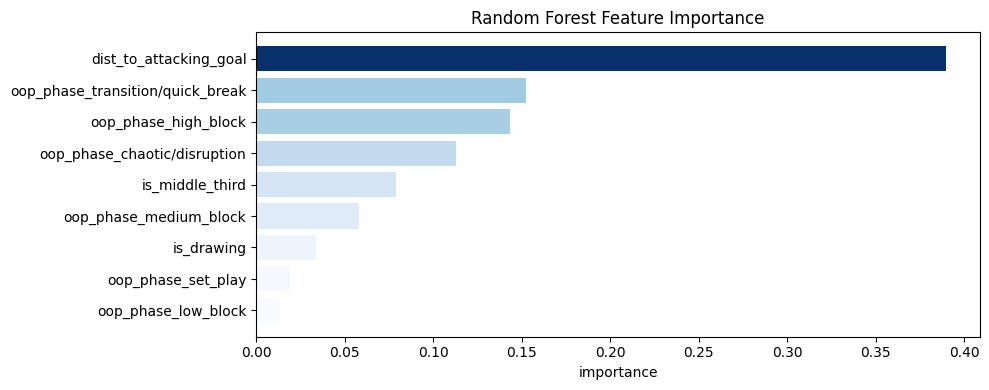

In [53]:
best_rf = rf_grid.best_estimator_

rf_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

plot_gradient_bars(rf_importance, "importance", "Random Forest Feature Importance", cmap="Blues")


C:\Users\Owner\AppData\Local\Temp\ipykernel_16216\796877662.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap)(norm)


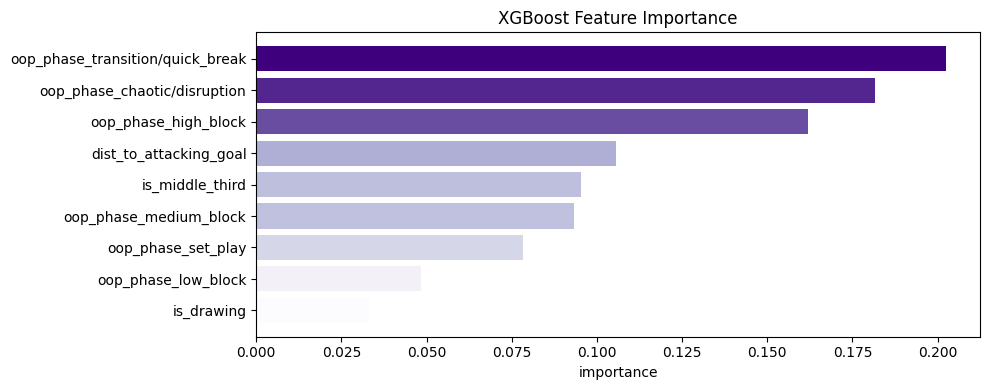

In [54]:
best_xgb = xgb_grid.best_estimator_

xgb_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": best_xgb.feature_importances_
}).sort_values("importance", ascending=False)

plot_gradient_bars(xgb_importance, "importance", "XGBoost Feature Importance", cmap="Purples")



C:\Users\Owner\AppData\Local\Temp\ipykernel_16216\796877662.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap)(norm)


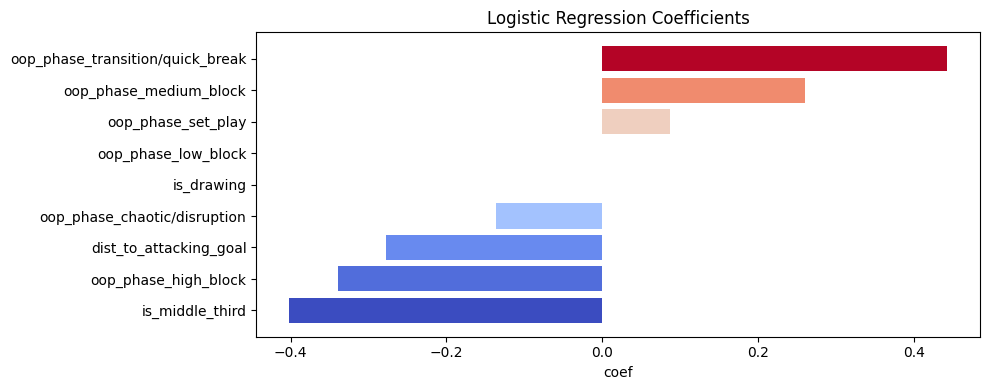

In [55]:
coefs = best_log_reg.named_steps["clf"].coef_[0]

logreg_importance = pd.DataFrame({
    "feature": X.columns,
    "coef": coefs
}).sort_values("coef", ascending=False)

plot_gradient_bars(
    logreg_importance,
    "coef",
    "Logistic Regression Coefficients",
    cmap="coolwarm"
)


In [56]:
pred_class = best_rf.predict(X_test)
pred_prob = best_rf.predict_proba(X_test)[:, 1]

X_test_df = pd.DataFrame(X_test, index=X_test.index, columns=X.columns)

X_test_df = X_test_df.reset_index().rename(columns={'index':'row_index'})


# Build a results dataframe
results = pd.DataFrame({
    "row_index": row_test.values,
    "true_value": y_test.values,
    "predicted_class": pred_class,
    "predicted_probability": pred_prob
})

full_results = results.merge(
    og_df, 
    left_on="row_index", 
    right_on="row_index",
    how="left"
)

full_results.to_csv('../../Our Datasets/classifier_results_rf.csv', index=False)


In [57]:
full_results

,row_index,true_value,predicted_class,predicted_probability,Unique ID,match_id,event_index,frame_anchor,rec_player_id,rec_team_short,dist_to_attacking_goal,team_out_of_possession_phase_type,player_targeted_dangerous,event_row_index,source_file,is_drawing,is_middle_third
0,5523,0,0,0.228408,2006229_46_46,2006229.0,46.0,288.0,159945.0,Melbourne City,54.282972,chaotic/disruption,0.0,5523,2006229.0,1,1
1,3151,0,0,0.212864,2011166_1195_1219,2011166.0,1195.0,16056.0,51028.0,Wellington P FC,91.049635,high_block,0.0,3151,2011166.0,1,0
2,5337,0,1,0.547421,1899585_2785_2785,1899585.0,2785.0,33937.0,23418.0,Auckland FC,33.820852,chaotic/disruption,0.0,5337,1899585.0,0,0
3,5628,0,0,0.319106,2011166_3649_3649,2011166.0,3649.0,64570.0,957734.0,Wellington P FC,73.451389,chaotic/disruption,0.0,5628,2011166.0,0,1
4,4320,1,1,0.655892,2015213_1928_1971,2015213.0,1928.0,24105.0,14736.0,Auckland FC,32.142744,low_block,1.0,4320,2015213.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,5743,0,0,0.315116,2015213_2043_2043,2015213.0,2043.0,25192.0,795527.0,Western United,64.827206,chaotic/disruption,0.0,5743,2015213.0,0,1
112,498,0,0,0.456690,1886347_4887_4896,1886347.0,4896.0,57138.0,43829.0,Auckland FC,38.683967,chaotic/disruption,0.0,498,1886347.0,0,0
113,5509,0,1,0.754716,1996435_4410_4410,1996435.0,4410.0,47363.0,797295.0,Adelaide United,13.497503,set_play,0.0,5509,1996435.0,0,0
114,3837,0,0,0.495626,2013725_3227_3237,2013725.0,3227.0,49941.0,133854.0,Sydney FC,49.951747,medium_block,0.0,3837,2013725.0,0,1
